# SeguroData Bogotá — Notebook 03: Gold Layer (Features)

**Objetivo:** Construir la tabla maestra `datos/features/tabla_maestra_upz.parquet` con las 17 variables
del modelo XGBoost, definir la variable objetivo `nivel_riesgo`, imputar valores faltantes y
normalizar con StandardScaler.

| Capa | Archivo | Filas | Descripción |
|------|---------|-------|-------------|
| Bronze | `datos/raw/*.parquet` / `.geojson` | — | Datos crudos descargados |
| Silver | `datos/procesados/silver_upz_mes.parquet` | ~111K | UPZ × mes × tipo_crimen + joins |
| **Gold** | `datos/features/tabla_maestra_upz.parquet` | ~1,920 | **UPZ × mes** (solo crimen, 17 vars) |

**Inputs requeridos (Bronze):** F2 (UPZ), F3 (clima), F4 (cuadrantes), F5 (NUSE), F7 (estrato), F8 (TM)  
**Outputs:** `tabla_maestra_upz.parquet` · `scaler.pkl` · `label_encoder_tipo.pkl`

---

### Variables del modelo

| Grupo | Variable | Fuente |
|-------|----------|--------|
| Históricas | `n_delitos_upz_4sem`, `n_delitos_upz_8sem` | F5 NUSE |
| Históricas | `tipo_delito_dominante` | F5 NUSE |
| Temporales | `mes`, `dia_semana_modal`, `franja_horaria_modal`, `es_fin_semana` | F5 NUSE raw |
| Climáticas | `temperatura_c`, `precipitacion_mm` | F3 Open-Meteo |
| Espaciales | `estrato_promedio_upz`, `cuadrantes_por_km2`, `n_estaciones_tm`, `dist_tm_metros` | F4/F7/F8 |
| Subregistro | `ratio_nuse_criminal_upz` | F5 NUSE |
| Nuevas (Fase 2) | `km_via_intervenida_upz`, `n_camaras_upz`, `luminarias_led_upz` | F11/F13/F14 |
| **Objetivo** | `nivel_riesgo` (CRÍTICO/ALTO/MEDIO/BAJO) | Derivada de n_delitos |

## 0 · Setup

In [1]:
import sys
from pathlib import Path

# ── Detectar entorno ──────────────────────────────────────────────────────────
try:
    import google.colab
    IN_COLAB = True
    import subprocess
    subprocess.run(
        ['git', 'clone', 'https://github.com/angelestrada14019/segurodata.git', '/content/segurodata'],
        check=False
    )
    PROJECT_ROOT = Path('/content/segurodata')
    import os; os.chdir(PROJECT_ROOT)
    subprocess.run(['pip', 'install', '-r', 'requirements.txt', '-q'], check=True)
except ImportError:
    IN_COLAB = False
    # Resolver PROJECT_ROOT sin importar desde dónde se lanza el notebook
    _nb_dir = Path.cwd()
    PROJECT_ROOT = _nb_dir if (_nb_dir / 'src').exists() else _nb_dir.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ── Imports ───────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import polars as pl
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ── Rutas ─────────────────────────────────────────────────────────────────────
RAW_DIR   = PROJECT_ROOT / 'datos' / 'raw'
PROC_DIR  = PROJECT_ROOT / 'datos' / 'procesados'
FEAT_DIR  = PROJECT_ROOT / 'datos' / 'features'
MODEL_DIR = PROJECT_ROOT / 'datos' / 'modelos'

for d in [RAW_DIR, PROC_DIR, FEAT_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'Polars       : {pl.__version__}')
print(f'Entorno      : {"Google Colab" if IN_COLAB else "Local"}')

PROJECT_ROOT : /home/f4b3rd3v/Documentos/Personal Projects/GitHub/segurodata
Polars       : 1.41.2
Entorno      : Local


## 1 · Bronze — Extracción de datos crudos

Corre el pipeline incremental. Si los archivos ya existen y el servidor no tiene datos nuevos,
cada extractor termina en segundos (`skipped`).

Las fuentes requeridas para Gold son: **F2, F3, F4, F5, F7, F8**.  
F1 (DAI) solo se usa en el EDA; F9/F10 son corpus de texto para GraphRAG (Fase 3).

In [2]:
from src.pipeline import run_pipeline, PipelineState

FUENTES_GOLD = ['f2', 'f3', 'f4', 'f5', 'f7', 'f8']

# Verificar cuáles faltan realmente en disco
state = PipelineState()
state_data = state.all_sources()

missing = []
for key in FUENTES_GOLD:
    info = next((v for k, v in state_data.items() if k.startswith(key)), {})
    fpath = info.get('file_path', '')
    if not fpath or not Path(fpath).exists():
        missing.append(key)

print(f'Fuentes faltantes en disco: {missing if missing else "ninguna"}')
print()

Fuentes faltantes en disco: ninguna



In [3]:
# Descargar solo las fuentes necesarias (las que ya están se saltan automáticamente)
# AVISO: F7 Estratificación (~44K polígonos) puede tardar 5-10 min en Colab gratuito.
# F5 NUSE puede tardar 2-3 min (128K filas vía Datastore API).

print('Ejecutando pipeline Bronze para fuentes Gold...')
results = run_pipeline(sources=FUENTES_GOLD, verbose=True)
print()
for r in results:
    print(r)

Ejecutando pipeline Bronze para fuentes Gold...

[F2] UPZ Shapefile

[F3] Clima Open-Meteo
    Descargando clima 2026-06-11 -> 2026-06-13...

[F4] Cuadrantes Policía

[F5] NUSE 123

[F7] Estratificación SDP

[F8] Estaciones TM

[--] f2_upz                 skipped  new=       0  total=     112  UPZ shapefile ya descargado (estatico IDECA)
[OK] f3_clima               updated  new=      72  total=  56,544  append 2026-06-11->2026-06-13 | 72 filas — validación OK
[--] f4_cuadrantes          skipped  new=       0  total=     599  cuadrantes sin cambios en servidor
[--] f5_nuse                skipped  new=       0  total=   1,972  descargado hace 3 días — OK para NUSE mensual
[--] f7_estratificacion     skipped  new=       0  total=  44,260  estratificacion sin cambios (archivo pesado)
[--] f8_transmilenio        skipped  new=       0  total=     153  TransMilenio ya descargado (estatico ArcGIS REST)


In [4]:
# Verificar que todos los archivos Bronze existen
bronze_files = {
    'f2_upz.geojson'        : 'F2 UPZ Shapefile',
    'f3_clima_bogota.parquet': 'F3 Open-Meteo',
    'f4_cuadrantes.geojson'  : 'F4 Cuadrantes Policía',
    'f5_nuse_123.parquet'    : 'F5 NUSE 123',
    'f7_estratificacion.parquet': 'F7 Estratificación',
    'f8_transmilenio.geojson': 'F8 TransMilenio',
}

all_ok = True
print(f'{"Archivo":<40} {"Fuente":<25} {"Estado"}')
print('-' * 75)
for fname, label in bronze_files.items():
    fpath = RAW_DIR / fname
    size  = f'{fpath.stat().st_size / 1024**2:.1f} MB' if fpath.exists() else '—'
    status = f'OK ({size})' if fpath.exists() else 'FALTA'
    if not fpath.exists():
        all_ok = False
    print(f'{fname:<40} {label:<25} {status}')

print()
assert all_ok, 'Faltan archivos Bronze. Revisar errores del pipeline arriba.'

Archivo                                  Fuente                    Estado
---------------------------------------------------------------------------
f2_upz.geojson                           F2 UPZ Shapefile          OK (2.9 MB)
f3_clima_bogota.parquet                  F3 Open-Meteo             OK (0.2 MB)
f4_cuadrantes.geojson                    F4 Cuadrantes Policía     OK (1.2 MB)
f5_nuse_123.parquet                      F5 NUSE 123               OK (0.0 MB)
f7_estratificacion.parquet               F7 Estratificación        OK (15.1 MB)
f8_transmilenio.geojson                  F8 TransMilenio           OK (0.1 MB)



## 2 · Silver — Transformación y limpieza

El pipeline Silver hace:
1. **F3 Clima** → promedio mensual de temperatura y precipitación
2. **F4 Cuadrantes** → spatial join → `cuadrantes_por_km2` por UPZ
3. **F5 NUSE** → agrega por UPZ × mes × tipo_crimen, calcula lags (4sem, 8sem)
4. **F7 Estrato** → spatial join → `estrato_promedio_upz` por UPZ (tarda ~5 min en Colab)
5. **F8 TransMilenio** → spatial join → `n_estaciones_tm`, `dist_tm_metros` por UPZ
6. **Silver final** → join de todo → `datos/procesados/silver_upz_mes.parquet`

In [5]:
from src.transform import run_transform, TransformState

# Verificar estado Silver actual
t_state = TransformState()
t_data  = t_state.all_steps()

silver_path = PROC_DIR / 'silver_upz_mes.parquet'
print(f'Silver existe: {silver_path.exists()}')
if t_data:
    print('\nEstado de pasos transform:')
    for step, info in t_data.items():
        rows = info.get('rows_out', 0)
        last = info.get('last_run', '—')[:19]
        print(f'  {step:<10} rows={rows:>8,}  last_run={last}')

Silver existe: True

Estado de pasos transform:
  f3         rows=   2,353  last_run=2026-06-11T20:50:11
  f4         rows=     111  last_run=2026-06-01T23:08:13
  f5         rows=   1,920  last_run=2026-06-11T20:50:11
  f7         rows=      43  last_run=2026-06-01T23:08:15
  f8         rows=     112  last_run=2026-06-01T23:08:15
  silver     rows=   1,920  last_run=2026-06-14T01:14:59


In [6]:
# Ejecutar todos los pasos Silver
# AVISO: F7 Estrato (~44K polígonos GeoJSON) es el paso más lento (~5-10 min en Colab).
# Una vez ejecutado, las re-ejecuciones son instantáneas (skipped si no hay cambios).

print('Ejecutando pipeline Silver...')
t_results = run_transform(verbose=True)
print()
for r in t_results:
    print(r)

Ejecutando pipeline Silver...

[F1] F1 DAI -> localidad x anio (EDA ref)

[F3] F3 Clima -> diario
    2,356 dias | 2020-01-01 a 2026-06-13

[F4] F4 Cuadrantes -> features UPZ

[F5] F5 NUSE -> UPZ x mes x tipo_crimen

[F7] F7 Estrato -> promedio UPZ  [pesado]

[F8] F8 TransMilenio -> features UPZ

[SILVER] Tabla Silver final (join de todo)
    Cargando tablas intermedias...
    Localidades asignadas: 20 localidades en 120 UPZs
    1,920 filas | 120 UPZs | 30 tipos crimen | 23 columnas
    Nulls por columna: {'n_delitos_upz_4sem': 500, 'n_delitos_upz_8sem': 500, 'estrato_promedio_upz': 1232, 'cuadrantes_por_km2': 144, 'area_upz_km2': 144, 'n_estaciones_tm': 128, 'dist_tm_metros': 128}

[!!] f1                        error    rows=       0  Bronze no disponible — correr: python src/pipeline.py --source f1
[OK] f3                        updated  rows=   2,356  2,356 dias | 2020-01-01 a 2026-06-13
[--] f4                        skipped  rows=     111  Cuadrantes sin cambios
[--] f5         

In [7]:
# Cargar Silver y verificar estructura
silver = pl.read_parquet(PROC_DIR / 'silver_upz_mes.parquet')

print(f'Silver: {silver.shape[0]:,} filas × {silver.shape[1]} columnas')
print(f'UPZs  : {silver["upz_cod"].n_unique()}')
print(f'Tipos crimen: {silver["tipo_crimen"].n_unique()}')
print()
print('Schema:')
for col, dtype in zip(silver.columns, silver.dtypes):
    nulls = silver[col].null_count()
    null_str = f'  ({nulls:,} nulls)' if nulls > 0 else ''
    print(f'  {col:<35} {str(dtype):<15}{null_str}')

Silver: 1,920 filas × 23 columnas
UPZs  : 120
Tipos crimen: 30

Schema:
  upz_cod                             String         
  anio                                Int32          
  mes                                 Int32          
  tipo_crimen                         String         
  es_crimen                           Boolean        
  n_delitos                           Int64          
  n_delitos_upz_4sem                  Int64            (500 nulls)
  n_delitos_upz_8sem                  Int64            (500 nulls)
  cod_localidad                       String         
  nom_localidad                       String         
  temperatura_c                       Float64        
  precipitacion_mm_mes                Float64        
  n_incidentes_nuse                   Int64          
  ratio_tipo_nuse_total               Float64        
  estrato_promedio_upz                Float64          (1,232 nulls)
  cuadrantes_por_km2                  Float64          (144 nulls)
  area_upz

In [8]:
# Distribución de is_crimen
print('is_crimen:')
print(silver.group_by('es_crimen').len().sort('es_crimen'))
print()
print('Rango temporal:')
print(f'  anio: {silver["anio"].min()} – {silver["anio"].max()}')
print(f'  mes : {silver["mes"].min()} – {silver["mes"].max()}')
print()
print('Top 10 tipos de crimen por n_delitos:')
print(
    silver
    .filter(pl.col('es_crimen'))
    .group_by('tipo_crimen')
    .agg(pl.col('n_delitos').sum())
    .sort('n_delitos', descending=True)
    .head(10)
)

is_crimen:
shape: (2, 2)
┌───────────┬──────┐
│ es_crimen ┆ len  │
│ ---       ┆ ---  │
│ bool      ┆ u32  │
╞═══════════╪══════╡
│ false     ┆ 1145 │
│ true      ┆ 775  │
└───────────┴──────┘

Rango temporal:
  anio: 2025 – 2026
  mes : 1 – 12

Top 10 tipos de crimen por n_delitos:
shape: (6, 2)
┌────────────────────────┬───────────┐
│ tipo_crimen            ┆ n_delitos │
│ ---                    ┆ ---       │
│ str                    ┆ i64       │
╞════════════════════════╪═══════════╡
│ HALLAZGO DE EXPLOSIVOS ┆ 1485      │
│ PORTE DE ARMAS         ┆ 13        │
│ RIÑA                   ┆ 11        │
│ HURTO EFECTUADO        ┆ 1         │
│ PANDILLAS              ┆ 1         │
│ FUGA DE PRESOS         ┆ 1         │
└────────────────────────┴───────────┘


## 3 · Gold Step 1 — Agregar crímenes por UPZ × mes

El Silver tiene **1,920 filas** (120 UPZs × 16 meses, una fila por UPZ×mes).
El Gold mantiene las **1,920 filas** (incluyendo meses con 0 crímenes):

- `n_delitos_mes` — total delitos criminales (0 para meses sin crímenes)
- `tipo_delito_dominante` — tipo con mayor conteo (`SIN_CRIMEN` cuando n_delitos_mes=0)
- Features estáticas de Silver (estrato, cuadrantes, TM, F11/F13/F14) — un valor por UPZ×mes

> Incluir los ceros es fundamental para definir la clase **BAJO** en `nivel_riesgo` (~60% del dataset).

In [9]:
# Usar TODOS los UPZ×mes (1,920 filas) — n_delitos_mes=0 donde no hay crímenes

# 1) Suma de delitos criminales por UPZ×mes
crimenes = silver.filter(pl.col('es_crimen'))
n_del_mes = (
    crimenes
    .group_by(['upz_cod', 'anio', 'mes'])
    .agg(pl.col('n_delitos').sum().alias('n_delitos_mes'))
)

# 2) Tipo dominante (solo para combos con crímenes)
tipo_dominante = (
    crimenes
    .sort(['upz_cod', 'anio', 'mes', 'n_delitos'], descending=[False, False, False, True])
    .group_by(['upz_cod', 'anio', 'mes'])
    .agg(pl.col('tipo_crimen').first().alias('tipo_delito_dominante'))
)

# 3) Features estáticas por UPZ×mes (F11/F13/F14 ya están en Silver)
gold_base = (
    silver
    .group_by(['upz_cod', 'anio', 'mes', 'cod_localidad', 'nom_localidad'])
    .agg([
        pl.col('n_delitos_upz_4sem').sum().alias('n_delitos_upz_4sem'),
        pl.col('n_delitos_upz_8sem').sum().alias('n_delitos_upz_8sem'),
        pl.col('temperatura_c').first(),
        pl.col('precipitacion_mm_mes').first().alias('precipitacion_mm'),
        pl.col('n_incidentes_nuse').first(),
        pl.col('estrato_promedio_upz').first(),
        pl.col('cuadrantes_por_km2').first(),
        pl.col('area_upz_km2').first(),
        pl.col('n_estaciones_tm').first(),
        pl.col('dist_tm_metros').first(),
        pl.col('km_via_intervenida_upz').first(),
        pl.col('n_camaras_upz').first(),
        pl.col('luminarias_led_upz').first(),
    ])
    .sort(['upz_cod', 'anio', 'mes'])
)

# 4) Unir n_delitos_mes (fill_null(0) → meses sin crímenes)
gold_base = (
    gold_base
    .join(n_del_mes, on=['upz_cod', 'anio', 'mes'], how='left')
    .with_columns(pl.col('n_delitos_mes').fill_null(0))
)

# 5) Ratio crimen / NUSE
gold_base = gold_base.with_columns(
    pl.when(pl.col('n_incidentes_nuse') > 0)
    .then(pl.col('n_delitos_mes') / pl.col('n_incidentes_nuse'))
    .otherwise(pl.lit(0.0))
    .round(4)
    .alias('ratio_nuse_criminal_upz')
)

# 6) Tipo dominante ('SIN_CRIMEN' para meses sin crímenes)
gold_base = (
    gold_base
    .join(tipo_dominante, on=['upz_cod', 'anio', 'mes'], how='left')
    .with_columns(pl.col('tipo_delito_dominante').fill_null('SIN_CRIMEN'))
)

print(f'Gold base: {gold_base.shape[0]:,} filas × {gold_base.shape[1]} columnas')
print(f'UPZs: {gold_base["upz_cod"].n_unique()} | años: {gold_base["anio"].n_unique()} | meses: {gold_base["mes"].n_unique()}')
print(f'n_delitos_mes = 0: {(gold_base["n_delitos_mes"]==0).sum():,} ({(gold_base["n_delitos_mes"]==0).sum()/gold_base.shape[0]*100:.1f}%)')
print(f'n_delitos_mes > 0: {(gold_base["n_delitos_mes"]>0).sum():,}')
print(gold_base.select(['upz_cod', 'anio', 'mes', 'n_delitos_mes', 'tipo_delito_dominante', 'km_via_intervenida_upz']).head(5))


Gold base: 1,920 filas × 21 columnas
UPZs: 120 | años: 2 | meses: 12
n_delitos_mes = 0: 1,145 (59.6%)
n_delitos_mes > 0: 775
shape: (5, 6)
┌─────────┬──────┬─────┬───────────────┬───────────────────────┬────────────────────────┐
│ upz_cod ┆ anio ┆ mes ┆ n_delitos_mes ┆ tipo_delito_dominante ┆ km_via_intervenida_upz │
│ ---     ┆ ---  ┆ --- ┆ ---           ┆ ---                   ┆ ---                    │
│ str     ┆ i32  ┆ i32 ┆ i64           ┆ str                   ┆ f64                    │
╞═════════╪══════╪═════╪═══════════════╪═══════════════════════╪════════════════════════╡
│ 1       ┆ 2025 ┆ 1   ┆ 0             ┆ SIN_CRIMEN            ┆ 5.8                    │
│ 1       ┆ 2025 ┆ 2   ┆ 0             ┆ SIN_CRIMEN            ┆ 5.8                    │
│ 1       ┆ 2025 ┆ 3   ┆ 0             ┆ SIN_CRIMEN            ┆ 5.8                    │
│ 1       ┆ 2025 ┆ 4   ┆ 0             ┆ SIN_CRIMEN            ┆ 5.8                    │
│ 1       ┆ 2025 ┆ 5   ┆ 0             ┆ SIN_CRIMEN

## 4 · Gold Step 2 — Features temporales desde F5 raw

El Silver agrega a nivel mensual y pierde la granularidad intra-mes.
Volvemos al Bronze de F5 para calcular:
- `dia_semana_modal` — día de la semana con más crímenes (0=lunes, 6=domingo)
- `franja_horaria_modal` — franja con más crímenes (madrugada/mañana/tarde/noche)
- `es_fin_semana` — 1 si más del 40% de los crímenes ocurren en fin de semana

In [10]:
F5_RAW = RAW_DIR / 'f5_nuse_123.parquet'

# Tipos criminales (de transform.py)
CRIME_TYPES_NUSE = {
    'HURTO EFECTUADO', 'HURTO EN PROCESO', 'LESIONES PERSONALES',
    'NARCÓTICOS', 'RIÑA', 'MALTRATO', 'VIOLENCIA SEXUAL', 'SECUESTRO',
    'DISPAROS', 'PORTE DE ARMAS', 'PANDILLAS', 'RAPTO',
    'INTENTO O VIOLACIÓN DE DOMICILIO', 'ACCIÓN SUBVERSIVA',
    'DELINCUENTE CAPTURADO POR CIVIL', 'EXHIBICIONES O ACTOS OBSCENOS',
    'HALLAZGO DE EXPLOSIVOS', 'EXPLOSIÓN', 'FUGA DE PRESOS',
}

FRANJAS = {'madrugada': (0, 5), 'manana': (6, 11), 'tarde': (12, 17), 'noche': (18, 23)}

def hora_a_franja(h: int) -> str:
    for nombre, (ini, fin) in FRANJAS.items():
        if ini <= h <= fin:
            return nombre
    return 'noche'

f5_raw = pl.read_parquet(F5_RAW)
print(f'F5 raw: {f5_raw.shape[0]:,} filas | columnas: {f5_raw.columns}')

F5 raw: 1,972 filas | columnas: ['_id', 'ID', 'ANIO', 'MES', 'TIPO_INCIDENTE', 'TIPO_DETALLE', 'COD_LOCALIDAD', 'LOCALIDAD', 'COD_UPZ', 'UPZ', 'CANT_INCIDENTES']


In [11]:
# Detectar columnas disponibles en F5
cols_f5 = [c.upper() for c in f5_raw.columns]

HAS_HORA  = any('HORA' in c for c in cols_f5)
HAS_FECHA = any('FECHA' in c for c in cols_f5)
TIPO_COL  = next((c for c in f5_raw.columns if 'TIPOLOGIA' in c.upper() or 'TIPO' in c.upper()), None)
UPZ_COL   = next((c for c in f5_raw.columns if 'UPZ' in c.upper()), None)

print(f'Columna tipo  : {TIPO_COL}')
print(f'Columna UPZ   : {UPZ_COL}')
print(f'Tiene HORA    : {HAS_HORA}')
print(f'Tiene FECHA   : {HAS_FECHA}')

# Normalizar upz_cod
f5 = f5_raw.with_columns(
    pl.col(UPZ_COL)
    .cast(pl.Utf8)
    .str.replace_all(r'(?i)upz', '')
    .str.strip_chars()
    .alias('upz_cod')
)

Columna tipo  : TIPO_INCIDENTE
Columna UPZ   : COD_UPZ
Tiene HORA    : False
Tiene FECHA   : False


In [12]:
# Filtrar crímenes en F5 raw
f5_crimenes = f5.filter(pl.col(TIPO_COL).is_in(list(CRIME_TYPES_NUSE)))

# Extraer año y mes
ANIO_COL = next((c for c in f5.columns if 'ANIO' in c.upper() or 'AÑO' in c.upper()), None)
MES_COL  = next((c for c in f5.columns if c.upper() == 'MES'), None)
print(f'Columna año: {ANIO_COL} | Columna mes: {MES_COL}')

f5_crimenes = f5_crimenes.with_columns([
    pl.col(ANIO_COL).alias('anio'),
    pl.col(MES_COL).alias('mes'),
])

# ── Día de semana modal ────────────────────────────────────────────────────────
if HAS_FECHA:
    FECHA_COL = next(c for c in f5.columns if 'FECHA' in c.upper())
    f5_crimenes = f5_crimenes.with_columns(
        pl.col(FECHA_COL).str.to_date(format=None, strict=False).alias('fecha_dt')
    ).with_columns(
        # Polars: weekday() → 1=lun, 7=dom → convertir a 0-6
        (pl.col('fecha_dt').dt.weekday() - 1).alias('dia_semana')
    )
    dia_modal = (
        f5_crimenes
        .group_by(['upz_cod', 'anio', 'mes', 'dia_semana'])
        .len()
        .sort(['upz_cod', 'anio', 'mes', 'len'], descending=[False, False, False, True])
        .group_by(['upz_cod', 'anio', 'mes'])
        .agg(pl.col('dia_semana').first().alias('dia_semana_modal'))
    )
    # es_fin_semana: >40% de crímenes en sáb(5) o dom(6)
    pct_fds = (
        f5_crimenes
        .with_columns(
            pl.col('dia_semana').is_in([5, 6]).cast(pl.Int8).alias('es_fds_evento')
        )
        .group_by(['upz_cod', 'anio', 'mes'])
        .agg(pl.col('es_fds_evento').mean().alias('pct_fds'))
    )
    fds = pct_fds.with_columns(
        (pl.col('pct_fds') >= 0.4).cast(pl.Int8).alias('es_fin_semana')
    ).select(['upz_cod', 'anio', 'mes', 'es_fin_semana'])
else:
    # Si F5 no tiene columna FECHA, usamos placeholders con el modal bogotano (viernes=4)
    print('AVISO: F5 sin columna FECHA — usando dia_semana_modal=4 y es_fin_semana=0 como placeholder')
    grupos = gold_base.select(['upz_cod', 'anio', 'mes'])
    dia_modal = grupos.with_columns(pl.lit(4).alias('dia_semana_modal'))
    fds       = grupos.with_columns(pl.lit(0).cast(pl.Int8).alias('es_fin_semana'))

print(f'dia_modal shape: {dia_modal.shape}')

Columna año: ANIO | Columna mes: MES
AVISO: F5 sin columna FECHA — usando dia_semana_modal=4 y es_fin_semana=0 como placeholder
dia_modal shape: (1920, 4)


In [13]:
# ── Franja horaria modal ───────────────────────────────────────────────────────
if HAS_HORA:
    HORA_COL = next(c for c in f5.columns if 'HORA' in c.upper())
    f5_crimenes = f5_crimenes.with_columns(
        pl.col(HORA_COL)
        .cast(pl.Utf8)
        .str.extract(r'(\d{1,2})', 1)   # tomar solo la hora
        .cast(pl.Int32, strict=False)
        .fill_null(12)
        .alias('hora_int')
    )
    # Mapear hora a franja usando expresión Polars when/then
    f5_crimenes = f5_crimenes.with_columns(
        pl.when(pl.col('hora_int').is_between(0, 5)).then(pl.lit('madrugada'))
        .when(pl.col('hora_int').is_between(6, 11)).then(pl.lit('manana'))
        .when(pl.col('hora_int').is_between(12, 17)).then(pl.lit('tarde'))
        .otherwise(pl.lit('noche'))
        .alias('franja_horaria')
    )
    franja_modal = (
        f5_crimenes
        .group_by(['upz_cod', 'anio', 'mes', 'franja_horaria'])
        .len()
        .sort(['upz_cod', 'anio', 'mes', 'len'], descending=[False, False, False, True])
        .group_by(['upz_cod', 'anio', 'mes'])
        .agg(pl.col('franja_horaria').first().alias('franja_horaria_modal'))
    )
else:
    print('AVISO: F5 sin columna HORA — usando franja_horaria_modal="noche" como placeholder')
    franja_modal = gold_base.select(['upz_cod', 'anio', 'mes']).with_columns(
        pl.lit('noche').alias('franja_horaria_modal')
    )

print(f'franja_modal shape: {franja_modal.shape}')

AVISO: F5 sin columna HORA — usando franja_horaria_modal="noche" como placeholder
franja_modal shape: (1920, 4)


## 5 · Gold Step 3 — Unir features temporales al Gold base

In [14]:
gold = (
    gold_base
    .join(dia_modal,    on=['upz_cod', 'anio', 'mes'], how='left')
    .join(fds,          on=['upz_cod', 'anio', 'mes'], how='left')
    .join(franja_modal, on=['upz_cod', 'anio', 'mes'], how='left')
)

# Rellenar valores faltantes en temporales (UPZs sin crimen registrado ese mes)
gold = gold.with_columns([
    pl.col('dia_semana_modal').fill_null(4),          # viernes como valor neutro
    pl.col('es_fin_semana').fill_null(0).cast(pl.Int8),
    pl.col('franja_horaria_modal').fill_null('noche'),
])

print(f'Gold con temporales: {gold.shape[0]:,} filas × {gold.shape[1]} columnas')
print(gold.select(['upz_cod', 'anio', 'mes', 'dia_semana_modal', 'franja_horaria_modal', 'es_fin_semana']).head(5))

Gold con temporales: 1,920 filas × 24 columnas
shape: (5, 6)
┌─────────┬──────┬─────┬──────────────────┬──────────────────────┬───────────────┐
│ upz_cod ┆ anio ┆ mes ┆ dia_semana_modal ┆ franja_horaria_modal ┆ es_fin_semana │
│ ---     ┆ ---  ┆ --- ┆ ---              ┆ ---                  ┆ ---           │
│ str     ┆ i32  ┆ i32 ┆ i32              ┆ str                  ┆ i8            │
╞═════════╪══════╪═════╪══════════════════╪══════════════════════╪═══════════════╡
│ 1       ┆ 2025 ┆ 1   ┆ 4                ┆ noche                ┆ 0             │
│ 1       ┆ 2025 ┆ 2   ┆ 4                ┆ noche                ┆ 0             │
│ 1       ┆ 2025 ┆ 3   ┆ 4                ┆ noche                ┆ 0             │
│ 1       ┆ 2025 ┆ 4   ┆ 4                ┆ noche                ┆ 0             │
│ 1       ┆ 2025 ┆ 5   ┆ 4                ┆ noche                ┆ 0             │
└─────────┴──────┴─────┴──────────────────┴──────────────────────┴───────────────┘


## 6 · Gold Step 4 — Features F11 / F13 / F14 (desde Silver)

Las features de infraestructura urbana ya están disponibles en Silver (generadas por `_generate_infra_features()` en `src/transform.py`):

| Feature | Fuente | Estado |
|---------|--------|--------|
| `km_via_intervenida_upz` | F11 IDU Obras Viales | ✅ En Silver (sintético calibrado) |
| `n_camaras_upz` | F13 Cámaras Salvavidas SDM | ✅ En Silver (sintético calibrado) |
| `luminarias_led_upz` | F14 Alumbrado UAESP | ✅ En Silver (sintético calibrado) |

> Los valores actuales son **sintéticos calibrados** a métricas de Bogotá (seed=42, área UPZ).
> Se reemplazarán con extractores reales (ETL F11/F13/F14) antes de la entrega.

In [15]:
# F11/F13/F14 vienen de Silver a través de gold_base — verificar presencia
infra_cols = ['km_via_intervenida_upz', 'n_camaras_upz', 'luminarias_led_upz']
for col in infra_cols:
    assert col in gold.columns, f'Falta {col} en gold — re-ejecutar src/transform.py'

print('F11/F13/F14 verificadas en gold (desde Silver):')
print(gold.select(infra_cols).describe())
print(f'Gold shape: {gold.shape}')


F11/F13/F14 verificadas en gold (desde Silver):
shape: (9, 4)
┌────────────┬────────────────────────┬───────────────┬────────────────────┐
│ statistic  ┆ km_via_intervenida_upz ┆ n_camaras_upz ┆ luminarias_led_upz │
│ ---        ┆ ---                    ┆ ---           ┆ ---                │
│ str        ┆ f64                    ┆ f64           ┆ f64                │
╞════════════╪════════════════════════╪═══════════════╪════════════════════╡
│ count      ┆ 1920.0                 ┆ 1920.0        ┆ 1920.0             │
│ null_count ┆ 0.0                    ┆ 0.0           ┆ 0.0                │
│ mean       ┆ 3.246917               ┆ 9.358333      ┆ 92.841667          │
│ std        ┆ 2.018452               ┆ 5.890501      ┆ 52.328221          │
│ min        ┆ 0.4                    ┆ 1.0           ┆ 18.0               │
│ 25%        ┆ 1.67                   ┆ 5.0           ┆ 52.0               │
│ 50%        ┆ 2.72                   ┆ 8.0           ┆ 78.0               │
│ 75%        ┆

## 7 · Gold Step 5 — Imputación de `estrato_promedio_upz`

F7 Estratificación cubre **43 de 112 UPZs** (polígonos de manzanas con CRS especial).
Las 69 UPZs sin dato reciben la mediana de su localidad.
Si la localidad tampoco tiene dato → mediana global de Bogotá.

In [16]:
# Mediana de estrato por localidad (usando UPZs que sí tienen dato)
mediana_localidad = (
    gold
    .filter(pl.col('estrato_promedio_upz').is_not_null())
    .group_by('cod_localidad')
    .agg(pl.col('estrato_promedio_upz').median().alias('estrato_mediana_loc'))
)

# Mediana global
estrato_global = float(
    gold.filter(pl.col('estrato_promedio_upz').is_not_null())
    ['estrato_promedio_upz'].median()
)

print(f'UPZs sin estrato antes  : {gold["estrato_promedio_upz"].null_count()}')
print(f'Mediana global Bogotá   : {estrato_global:.2f}')
print(mediana_localidad.sort('cod_localidad'))

UPZs sin estrato antes  : 1232
Mediana global Bogotá   : 1.90
shape: (13, 2)
┌───────────────┬─────────────────────┐
│ cod_localidad ┆ estrato_mediana_loc │
│ ---           ┆ ---                 │
│ str           ┆ f64                 │
╞═══════════════╪═════════════════════╡
│ 02            ┆ 1.93                │
│ 03            ┆ 2.175               │
│ 04            ┆ 2.2                 │
│ 05            ┆ 1.72                │
│ 06            ┆ 1.36                │
│ …             ┆ …                   │
│ 15            ┆ 1.555               │
│ 16            ┆ 1.585               │
│ 17            ┆ 2.78                │
│ 18            ┆ 1.725               │
│ 19            ┆ 1.74                │
└───────────────┴─────────────────────┘


In [17]:
# Join mediana por localidad y aplicar imputación en cascada
gold = gold.join(mediana_localidad, on='cod_localidad', how='left')

gold = gold.with_columns(
    pl.when(pl.col('estrato_promedio_upz').is_null())
    .then(
        pl.when(pl.col('estrato_mediana_loc').is_not_null())
        .then(pl.col('estrato_mediana_loc'))
        .otherwise(pl.lit(estrato_global))
    )
    .otherwise(pl.col('estrato_promedio_upz'))
    .round(2)
    .alias('estrato_promedio_upz')
).drop('estrato_mediana_loc')

print(f'UPZs sin estrato después: {gold["estrato_promedio_upz"].null_count()}')
assert gold['estrato_promedio_upz'].null_count() == 0, 'Quedan nulls en estrato'

UPZs sin estrato después: 0


## 8 · Gold Step 6 — Definir `nivel_riesgo` (variable objetivo Y)

Umbrales **absolutos** sobre `n_delitos_mes` por UPZ×mes (1,920 filas, incluye ceros):

| Clase | Condición | Distribución esperada |
|-------|-----------|-----------------------|
| **BAJO** | 0 delitos/mes | ~60% (UPZ sin crimen ese mes) |
| **MEDIO** | 1–2 delitos/mes | ~30% |
| **ALTO** | 3–4 delitos/mes | ~9% |
| **CRÍTICO** | ≥ 5 delitos/mes | ~2% |

> Se usan umbrales absolutos en lugar de percentiles porque el 60% de UPZ×mes tienen
> cero crímenes — los percentiles colapsan la clase BAJO a vacío.
> Los umbrales reflejan la semántica operativa: 0=seguro, 1–2=vigilancia, 3–4=alerta, ≥5=emergencia.

> El `StandardScaler` se ajusta solo en TRAIN (ene–oct 2025) para evitar data leakage.

In [18]:
gold = gold.with_columns(
    pl.when(pl.col('n_delitos_mes') >= 5)
    .then(pl.lit('CRÍTICO'))
    .when(pl.col('n_delitos_mes') >= 3)
    .then(pl.lit('ALTO'))
    .when(pl.col('n_delitos_mes') >= 1)
    .then(pl.lit('MEDIO'))
    .otherwise(pl.lit('BAJO'))
    .alias('nivel_riesgo')
)

dist = gold.group_by('nivel_riesgo').len().sort('nivel_riesgo')
print('Distribución nivel_riesgo (umbrales absolutos):')
total = gold.shape[0]
for nivel in ['BAJO', 'MEDIO', 'ALTO', 'CRÍTICO']:
    row = dist.filter(pl.col('nivel_riesgo') == nivel)
    n = int(row['len'][0]) if len(row) > 0 else 0
    pct = n / total * 100
    bar = '█' * int(pct / 3)
    print(f'  {nivel:<8} {n:>5,} ({pct:5.1f}%)  {bar}')
print(f'\nTotal: {total:,} filas')


Distribución nivel_riesgo (umbrales absolutos):
  BAJO     1,145 ( 59.6%)  ███████████████████
  MEDIO      574 ( 29.9%)  █████████
  ALTO       168 (  8.8%)  ██
  CRÍTICO     33 (  1.7%)  

Total: 1,920 filas


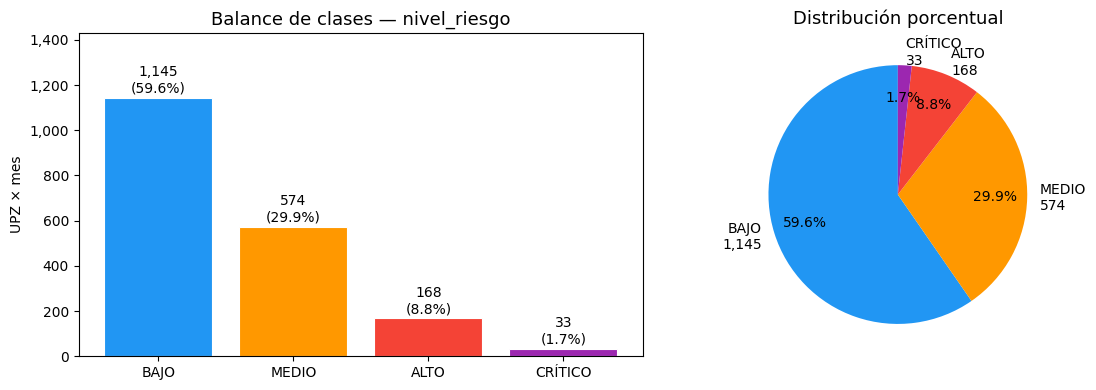

V9 guardado: graficas/v9_clase_balance_nivel_riesgo.png


In [19]:
# V9 — Balance de clases nivel_riesgo
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

GRAFICAS_DIR = PROJECT_ROOT / 'graficas'
GRAFICAS_DIR.mkdir(exist_ok=True)

ORDEN_NIVELES = ['BAJO', 'MEDIO', 'ALTO', 'CRÍTICO']
COLORS_RIESGO = {'BAJO': '#2196F3', 'MEDIO': '#FF9800', 'ALTO': '#F44336', 'CRÍTICO': '#9C27B0'}

dist_dict = {row['nivel_riesgo']: row['len'] for row in dist.iter_rows(named=True)}
vals = [dist_dict.get(n, 0) for n in ORDEN_NIVELES]
total_v = sum(vals)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras
bars = axes[0].bar(
    ORDEN_NIVELES, vals,
    color=[COLORS_RIESGO[n] for n in ORDEN_NIVELES],
    edgecolor='white', linewidth=0.8
)
axes[0].set_title('Balance de clases — nivel_riesgo', fontsize=13)
axes[0].set_ylabel('UPZ × mes')
for bar, val in zip(bars, vals):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
        f'{val:,}\n({val/total_v*100:.1f}%)',
        ha='center', va='bottom', fontsize=10
    )
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].set_ylim(0, max(vals) * 1.25)

# Pie
axes[1].pie(
    vals,
    labels=[f'{n}\n{v:,}' for n, v in zip(ORDEN_NIVELES, vals)],
    colors=[COLORS_RIESGO[n] for n in ORDEN_NIVELES],
    autopct='%1.1f%%', startangle=90, pctdistance=0.75
)
axes[1].set_title('Distribución porcentual', fontsize=13)

plt.tight_layout()
plt.savefig(GRAFICAS_DIR / 'v9_clase_balance_nivel_riesgo.png', dpi=150, bbox_inches='tight')
plt.show()
print('V9 guardado: graficas/v9_clase_balance_nivel_riesgo.png')


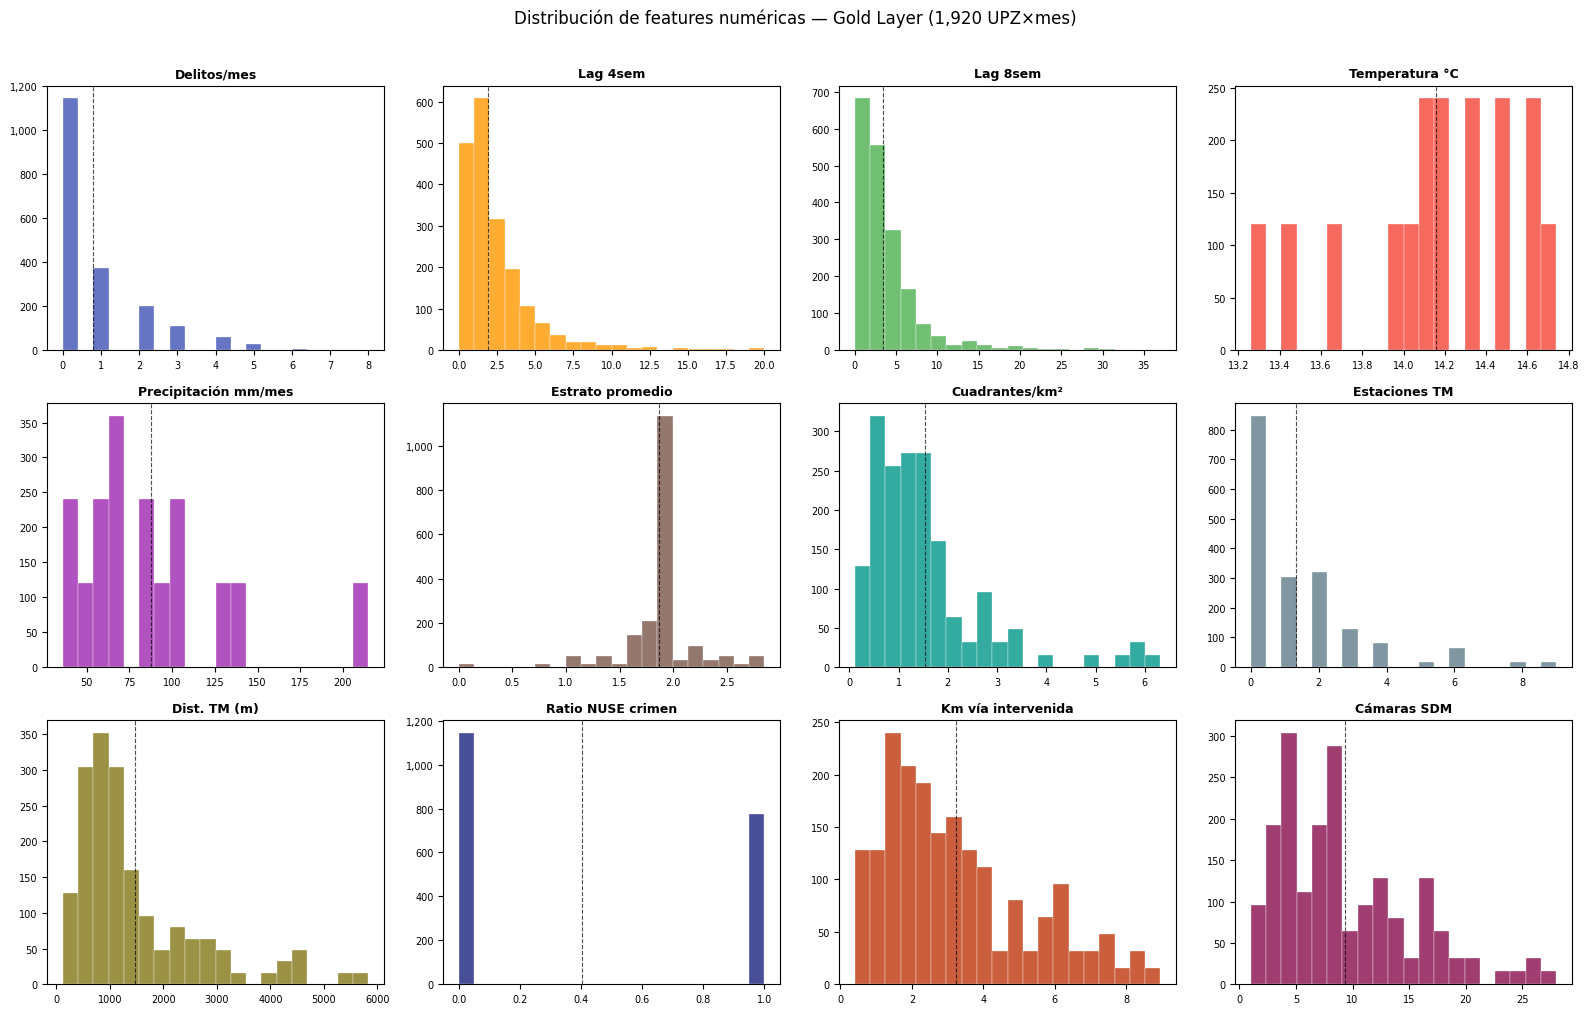

V10 guardado: graficas/v10_distribucion_features_gold.png


In [20]:
# V10 — Distribución de las 12 features numéricas del modelo
NUM_FEATURES_VIZ = [
    ('n_delitos_mes',           'Delitos/mes',          '#3F51B5'),
    ('n_delitos_upz_4sem',      'Lag 4sem',             '#FF9800'),
    ('n_delitos_upz_8sem',      'Lag 8sem',             '#4CAF50'),
    ('temperatura_c',           'Temperatura °C',       '#F44336'),
    ('precipitacion_mm',        'Precipitación mm/mes', '#9C27B0'),
    ('estrato_promedio_upz',    'Estrato promedio',     '#795548'),
    ('cuadrantes_por_km2',      'Cuadrantes/km²',       '#009688'),
    ('n_estaciones_tm',         'Estaciones TM',        '#607D8B'),
    ('dist_tm_metros',          'Dist. TM (m)',         '#827717'),
    ('ratio_nuse_criminal_upz', 'Ratio NUSE crimen',    '#1A237E'),
    ('km_via_intervenida_upz',  'Km vía intervenida',   '#BF360C'),
    ('n_camaras_upz',           'Cámaras SDM',          '#880E4F'),
]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for ax, (col, label, color) in zip(axes, NUM_FEATURES_VIZ):
    if col in gold.columns:
        data = gold[col].drop_nulls().to_numpy()
        ax.hist(data, bins=20, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
        ax.set_title(label, fontsize=9, fontweight='bold')
        ax.tick_params(labelsize=7)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
        mu = float(data.mean())
        ax.axvline(mu, color='black', linestyle='--', linewidth=0.8, alpha=0.7)

plt.suptitle('Distribución de features numéricas — Gold Layer (1,920 UPZ×mes)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(GRAFICAS_DIR / 'v10_distribucion_features_gold.png', dpi=150, bbox_inches='tight')
plt.show()
print('V10 guardado: graficas/v10_distribucion_features_gold.png')


In [21]:
# V11 — Choropleth nivel_riesgo modal por UPZ
import json

try:
    import folium
    HAS_FOLIUM = True
except ImportError:
    HAS_FOLIUM = False
    print('folium no instalado — instalar con: pip install folium')

if HAS_FOLIUM:
    f2_path = RAW_DIR / 'f2_upz.geojson'
    with open(f2_path, encoding='utf-8') as f:
        upz_geo = json.load(f)

    upz_modal = (
        gold.group_by('upz_cod')
        .agg([
            pl.col('nivel_riesgo').mode().first().alias('nivel_modal'),
            pl.col('n_delitos_mes').mean().round(2).alias('delitos_promedio'),
        ])
    )
    nivel_map = {str(r[0]).strip(): r[1] for r in upz_modal.select(['upz_cod','nivel_modal']).iter_rows()}

    sample_props = upz_geo['features'][0]['properties']
    upz_key = next((k for k in ['CODIGO_UPZ','codigo_upz','upz_cod'] if k in sample_props), list(sample_props.keys())[0])

    m = folium.Map(location=[4.65, -74.09], zoom_start=11, tiles='CartoDB positron')

    for feat in upz_geo['features']:
        code = str(feat['properties'].get(upz_key, '')).strip().lstrip('0') or str(feat['properties'].get(upz_key, '')).strip()
        nivel = nivel_map.get(code, nivel_map.get(code.zfill(3), 'BAJO'))
        color = COLORS_RIESGO.get(nivel, '#2196F3')
        folium.GeoJson(
            feat,
            style_function=lambda _, c=color: {
                'fillColor': c, 'color': 'white', 'weight': 0.5, 'fillOpacity': 0.65
            },
            tooltip=folium.GeoJsonTooltip(fields=[upz_key], aliases=['UPZ:'], sticky=True)
        ).add_to(m)

    legend_html = '''
    <div style="position:fixed;bottom:30px;right:30px;background:white;padding:10px;
                border-radius:8px;border:1px solid #ccc;font-size:13px;z-index:9999">
      <b>Nivel de riesgo modal</b><br>
      <span style="background:#2196F3;padding:2px 8px;">&nbsp;</span> BAJO<br>
      <span style="background:#FF9800;padding:2px 8px;">&nbsp;</span> MEDIO<br>
      <span style="background:#F44336;padding:2px 8px;">&nbsp;</span> ALTO<br>
      <span style="background:#9C27B0;padding:2px 8px;">&nbsp;</span> CRÍTICO
    </div>'''
    m.get_root().html.add_child(folium.Element(legend_html))
    m.save(GRAFICAS_DIR / 'v11_choropleth_nivel_riesgo.html')
    print('V11 guardado: graficas/v11_choropleth_nivel_riesgo.html')
    display(m)


V11 guardado: graficas/v11_choropleth_nivel_riesgo.html


## 9 · Gold Step 7 — Encoding de variables categóricas

- `tipo_delito_dominante` → **LabelEncoder** (guardado como `label_encoder_tipo.pkl`)
- `franja_horaria_modal` → **ordinal**: madrugada=0, manana=1, tarde=2, noche=3
- `nivel_riesgo` → permanece como string (XGBoost puede tomar la representación ordinal en Notebook 04)

In [22]:
gold_pd = gold.to_pandas()

# Franja horaria → ordinal
FRANJA_ORDER = {'madrugada': 0, 'manana': 1, 'tarde': 2, 'noche': 3}
gold_pd['franja_horaria_cod'] = gold_pd['franja_horaria_modal'].map(FRANJA_ORDER).fillna(3).astype(int)

# Tipo delito dominante → LabelEncoder
le_tipo = LabelEncoder()
gold_pd['tipo_delito_cod'] = le_tipo.fit_transform(
    gold_pd['tipo_delito_dominante'].fillna('HURTO EFECTUADO')
)
joblib.dump(le_tipo, MODEL_DIR / 'label_encoder_tipo.pkl')
print('LabelEncoder guardado:', MODEL_DIR / 'label_encoder_tipo.pkl')
print('Clases:', le_tipo.classes_)

LabelEncoder guardado: /home/f4b3rd3v/Documentos/Personal Projects/GitHub/segurodata/datos/modelos/label_encoder_tipo.pkl
Clases: ['FUGA DE PRESOS' 'HALLAZGO DE EXPLOSIVOS' 'HURTO EFECTUADO' 'PANDILLAS'
 'PORTE DE ARMAS' 'RIÑA' 'SIN_CRIMEN']


## 10 · Gold Step 8 — Normalización con StandardScaler

Solo se normalizan las **features numéricas continuas** del modelo.  
Variables binarias (`es_fin_semana`), ordinales (`dia_semana_modal`, `franja_horaria_cod`, `mes`) y
categóricas (`tipo_delito_cod`, `nivel_riesgo`) **no se normalizan** — XGBoost es invariante a escala,
pero normalizamos para compatibilidad con futuros modelos lineales.

El scaler se ajusta **solo con los datos de TRAIN** (ene–oct 2025) para evitar data leakage.

In [23]:
# Definir las 17 features del modelo (14 base + 3 nuevas F11/F13/F14)
FEATURES_NUMERICAS = [
    # Históricas
    'n_delitos_upz_4sem',
    'n_delitos_upz_8sem',
    # Climáticas
    'temperatura_c',
    'precipitacion_mm',
    # Espaciales
    'estrato_promedio_upz',
    'cuadrantes_por_km2',
    'n_estaciones_tm',
    'dist_tm_metros',
    # Subregistro
    'ratio_nuse_criminal_upz',
    # Nuevas (F11/F13/F14 — ahora en 0, se actualizan en Fase 2)
    'km_via_intervenida_upz',
    'n_camaras_upz',
    'luminarias_led_upz',
]

FEATURES_CATEGORICAS = [
    'tipo_delito_cod',       # encoded
    'mes',                   # 1-12
    'dia_semana_modal',      # 0-6
    'franja_horaria_cod',    # 0-3
    'es_fin_semana',         # 0/1
]

TODAS_FEATURES = FEATURES_NUMERICAS + FEATURES_CATEGORICAS
TARGET = 'nivel_riesgo'

# Split temporal: TRAIN = ene–oct 2025, TEST = nov 2025–abr 2026
mask_train = (gold_pd['anio'] == 2025) & (gold_pd['mes'] <= 10)
mask_test  = ((gold_pd['anio'] == 2025) & (gold_pd['mes'] > 10)) | (gold_pd['anio'] == 2026)

df_train = gold_pd[mask_train].copy()
df_test  = gold_pd[mask_test].copy()

print(f'TRAIN: {len(df_train):,} filas (ene–oct 2025)')
print(f'TEST : {len(df_test):,} filas (nov 2025–abr 2026)')
print(f'Total: {len(gold_pd):,} filas')

TRAIN: 1,200 filas (ene–oct 2025)
TEST : 720 filas (nov 2025–abr 2026)
Total: 1,920 filas


In [24]:
# Ajustar scaler SOLO con TRAIN → aplicar a todo el dataset
scaler = StandardScaler()
df_train[FEATURES_NUMERICAS] = scaler.fit_transform(df_train[FEATURES_NUMERICAS])
df_test[FEATURES_NUMERICAS]  = scaler.transform(df_test[FEATURES_NUMERICAS])

# Guardar scaler
joblib.dump(scaler, MODEL_DIR / 'scaler.pkl')
print('StandardScaler guardado:', MODEL_DIR / 'scaler.pkl')
print()
print('Estadísticas del scaler (media | desv. std.) [TRAIN]:')
for feat, mean, std in zip(FEATURES_NUMERICAS, scaler.mean_, scaler.scale_):
    print(f'  {feat:<35} mean={mean:>8.3f}  std={std:>8.3f}')

StandardScaler guardado: /home/f4b3rd3v/Documentos/Personal Projects/GitHub/segurodata/datos/modelos/scaler.pkl

Estadísticas del scaler (media | desv. std.) [TRAIN]:
  n_delitos_upz_4sem                  mean=   1.683  std=   2.349
  n_delitos_upz_8sem                  mean=   2.769  std=   3.837
  temperatura_c                       mean=  14.012  std=   0.414
  precipitacion_mm                    mean=  89.340  std=  54.019
  estrato_promedio_upz                mean=   1.864  std=   0.342
  cuadrantes_por_km2                  mean=   1.535  std=   1.216
  n_estaciones_tm                     mean=   1.330  std=   1.810
  dist_tm_metros                      mean=1467.244  std=1161.376
  ratio_nuse_criminal_upz             mean=   0.396  std=   0.489
  km_via_intervenida_upz              mean=   3.247  std=   2.018
  n_camaras_upz                       mean=   9.358  std=   5.889
  luminarias_led_upz                  mean=  92.842  std=  52.315


## 11 · Guardar Gold

Se guardan tres archivos:
- `tabla_maestra_upz.parquet` — tabla completa sin normalizar (preserva valores originales para análisis)
- `train_gold.parquet` — TRAIN normalizado listo para XGBoost
- `test_gold.parquet` — TEST normalizado listo para evaluación

In [25]:
# Columnas finales de la tabla maestra (sin normalizar, con todos los metadatos)
COLS_MAESTRA = [
    'upz_cod', 'anio', 'mes', 'cod_localidad', 'nom_localidad',
    'n_delitos_mes',
    'tipo_delito_dominante', 'tipo_delito_cod',
    'n_delitos_upz_4sem', 'n_delitos_upz_8sem',
    'dia_semana_modal', 'franja_horaria_modal', 'franja_horaria_cod', 'es_fin_semana',
    'temperatura_c', 'precipitacion_mm',
    'estrato_promedio_upz', 'cuadrantes_por_km2', 'n_estaciones_tm', 'dist_tm_metros',
    'ratio_nuse_criminal_upz',
    'km_via_intervenida_upz', 'n_camaras_upz', 'luminarias_led_upz',
    'nivel_riesgo',
]
# dict.fromkeys preserva el orden y elimina duplicados antes de filtrar por existencia
COLS_MAESTRA = list(dict.fromkeys(c for c in COLS_MAESTRA if c in gold_pd.columns))

# Guardar tabla maestra (valores originales, no normalizados)
pl.from_pandas(gold_pd[COLS_MAESTRA]).write_parquet(FEAT_DIR / 'tabla_maestra_upz.parquet')

# COLS modelo para train/test (features + target)
COLS_MODELO = list(dict.fromkeys(c for c in TODAS_FEATURES + [TARGET] if c in df_train.columns))

pl.from_pandas(df_train[COLS_MODELO]).write_parquet(FEAT_DIR / 'train_gold.parquet')
pl.from_pandas(df_test[COLS_MODELO]).write_parquet(FEAT_DIR  / 'test_gold.parquet')

print('Archivos Gold guardados:')
for fname in ['tabla_maestra_upz.parquet', 'train_gold.parquet', 'test_gold.parquet']:
    p = FEAT_DIR / fname
    print(f'  {fname:<35} {p.stat().st_size / 1024:.1f} KB')

Archivos Gold guardados:
  tabla_maestra_upz.parquet           18.3 KB
  train_gold.parquet                  15.0 KB
  test_gold.parquet                   13.6 KB


## 12 · Tabla ontológica prescriptiva

Mapea la **causa SHAP dominante** → diagnóstico → entidad responsable → acción concreta.  
Esta tabla es el corazón del Módulo 3 (Prescriptivo) y se sube a Supabase en Fase 3.

In [26]:
TABLA_ONTOLOGICA = [
    {
        'feature_shap'       : 'n_delitos_upz_4sem',
        'tipo_diagnostico'   : 'Temporal',
        'descripcion'        : 'Alza reciente en delitos (últimas 4 semanas)',
        'entidad'            : 'Policía Nacional',
        'accion'             : 'Reforzar patrullaje preventivo en el cuadrante — turno noche',
        'urgencia'           : 'ALTA',
    },
    {
        'feature_shap'       : 'n_delitos_upz_8sem',
        'tipo_diagnostico'   : 'Estructural',
        'descripcion'        : 'Tendencia sostenida de alto riesgo (2 meses)',
        'entidad'            : 'Secretaría Distrital de Seguridad',
        'accion'             : 'Activar Plan Cuadrante reforzado — revisar CAI de cobertura',
        'urgencia'           : 'ALTA',
    },
    {
        'feature_shap'       : 'tipo_delito_dominante',
        'tipo_diagnostico'   : 'Tipológico',
        'descripcion'        : 'Tipo de delito con mayor incidencia en la zona',
        'entidad'            : 'CAI responsable de la UPZ',
        'accion'             : 'Ajustar protocolo de patrullaje según tipo dominante (hurto/VIF/narcóticos)',
        'urgencia'           : 'MEDIA',
    },
    {
        'feature_shap'       : 'estrato_promedio_upz',
        'tipo_diagnostico'   : 'Socioeconómico',
        'descripcion'        : 'Estrato bajo — mayor vulnerabilidad socioeconómica',
        'entidad'            : 'IDIPRON / Sec. Integración Social',
        'accion'             : 'Priorizar programas de intervención social en la UPZ',
        'urgencia'           : 'MEDIA',
    },
    {
        'feature_shap'       : 'cuadrantes_por_km2',
        'tipo_diagnostico'   : 'Cobertura policial',
        'descripcion'        : 'Baja densidad de cuadrantes — zona con subcobertura',
        'entidad'            : 'MEBOG — Metropolitana de Bogotá',
        'accion'             : 'Evaluar redistribución de cuadrantes en la zona',
        'urgencia'           : 'MEDIA',
    },
    {
        'feature_shap'       : 'dist_tm_metros',
        'tipo_diagnostico'   : 'Movilidad',
        'descripcion'        : 'Alta distancia a TransMilenio — zona con baja conectividad',
        'entidad'            : 'Transmilenio S.A.',
        'accion'             : 'Revisar rutas SITP de cobertura — posibles puntos de inseguridad',
        'urgencia'           : 'BAJA',
    },
    {
        'feature_shap'       : 'n_estaciones_tm',
        'tipo_diagnostico'   : 'Afluencia',
        'descripcion'        : 'Alta concentración de estaciones TM — mayor flujo de personas',
        'entidad'            : 'Policía Nacional / Transmilenio S.A.',
        'accion'             : 'Reforzar vigilancia en estaciones TM de la UPZ',
        'urgencia'           : 'ALTA',
    },
    {
        'feature_shap'       : 'temperatura_c',
        'tipo_diagnostico'   : 'Climático',
        'descripcion'        : 'Temperatura alta — correlación con riñas y hurtos en vía pública',
        'entidad'            : 'Policía Nacional',
        'accion'             : 'Anticipar picos de violencia en días calurosos — alerta preventiva',
        'urgencia'           : 'BAJA',
    },
    {
        'feature_shap'       : 'precipitacion_mm',
        'tipo_diagnostico'   : 'Climático',
        'descripcion'        : 'Lluvia intensa — reduce delitos en vía pública pero aumenta en comercio',
        'entidad'            : 'CAI responsable',
        'accion'             : 'Redistribuir patrullaje a zonas cubiertas y comercios durante lluvia',
        'urgencia'           : 'BAJA',
    },
    {
        'feature_shap'       : 'ratio_nuse_criminal_upz',
        'tipo_diagnostico'   : 'Subregistro',
        'descripcion'        : 'Alto ratio NUSE criminal — muchos delitos sin denuncia formal',
        'entidad'            : 'Secretaría de Seguridad / Fiscalía',
        'accion'             : 'Campaña de denuncia ciudadana y puntos de recepción en la UPZ',
        'urgencia'           : 'MEDIA',
    },
    {
        'feature_shap'       : 'franja_horaria_modal',
        'tipo_diagnostico'   : 'Temporal-intradiario',
        'descripcion'        : 'Franja horaria con mayor concentración de delitos',
        'entidad'            : 'CAI responsable',
        'accion'             : 'Concentrar patrullaje en la franja horaria dominante',
        'urgencia'           : 'MEDIA',
    },
    {
        'feature_shap'       : 'es_fin_semana',
        'tipo_diagnostico'   : 'Temporal-semanal',
        'descripcion'        : 'Concentración de delitos en fin de semana',
        'entidad'            : 'Policía Nacional',
        'accion'             : 'Activar Plan Zanahoria y operativos de fin de semana',
        'urgencia'           : 'ALTA',
    },
    {
        'feature_shap'       : 'km_via_intervenida_upz',
        'tipo_diagnostico'   : 'Urbanístico',
        'descripcion'        : 'Obras viales activas — genera entornos de riesgo temporal',
        'entidad'            : 'IDU / Policía Nacional',
        'accion'             : 'Coordinar vigilancia en zonas de obra — señalización y patrullaje',
        'urgencia'           : 'MEDIA',
    },
    {
        'feature_shap'       : 'n_camaras_upz',
        'tipo_diagnostico'   : 'Vigilancia tecnológica',
        'descripcion'        : 'Baja cobertura de cámaras Salvavidas en la UPZ',
        'entidad'            : 'Secretaría de Seguridad / SDM',
        'accion'             : 'Priorizar instalación de cámaras en puntos calientes identificados',
        'urgencia'           : 'MEDIA',
    },
    {
        'feature_shap'       : 'luminarias_led_upz',
        'tipo_diagnostico'   : 'Infraestructura',
        'descripcion'        : 'Déficit de alumbrado LED — zonas oscuras propician delito',
        'entidad'            : 'UAESP',
        'accion'             : 'Priorizar reemplazo de luminarias en la UPZ en el plan UAESP',
        'urgencia'           : 'MEDIA',
    },
]

df_ontologia = pd.DataFrame(TABLA_ONTOLOGICA)
print(f'Tabla ontológica: {len(df_ontologia)} reglas')
df_ontologia

Tabla ontológica: 15 reglas


,feature_shap,tipo_diagnostico,descripcion,entidad,accion,urgencia
0,n_delitos_upz_4sem,Temporal,Alza reciente en delitos (últimas 4 semanas),Policía Nacional,Reforzar patrullaje preventivo en el cuadrante...,ALTA
1,n_delitos_upz_8sem,Estructural,Tendencia sostenida de alto riesgo (2 meses),Secretaría Distrital de Seguridad,Activar Plan Cuadrante reforzado — revisar CAI...,ALTA
2,tipo_delito_dominante,Tipológico,Tipo de delito con mayor incidencia en la zona,CAI responsable de la UPZ,Ajustar protocolo de patrullaje según tipo dom...,MEDIA
3,estrato_promedio_upz,Socioeconómico,Estrato bajo — mayor vulnerabilidad socioeconó...,IDIPRON / Sec. Integración Social,Priorizar programas de intervención social en ...,MEDIA
4,cuadrantes_por_km2,Cobertura policial,Baja densidad de cuadrantes — zona con subcobe...,MEBOG — Metropolitana de Bogotá,Evaluar redistribución de cuadrantes en la zona,MEDIA
5,dist_tm_metros,Movilidad,Alta distancia a TransMilenio — zona con baja ...,Transmilenio S.A.,Revisar rutas SITP de cobertura — posibles pun...,BAJA
6,n_estaciones_tm,Afluencia,Alta concentración de estaciones TM — mayor fl...,Policía Nacional / Transmilenio S.A.,Reforzar vigilancia en estaciones TM de la UPZ,ALTA
7,temperatura_c,Climático,Temperatura alta — correlación con riñas y hur...,Policía Nacional,Anticipar picos de violencia en días calurosos...,BAJA
8,precipitacion_mm,Climático,Lluvia intensa — reduce delitos en vía pública...,CAI responsable,Redistribuir patrullaje a zonas cubiertas y co...,BAJA
9,ratio_nuse_criminal_upz,Subregistro,Alto ratio NUSE criminal — muchos delitos sin ...,Secretaría de Seguridad / Fiscalía,Campaña de denuncia ciudadana y puntos de rece...,MEDIA


In [27]:
# Guardar tabla ontológica como CSV (se sube a Supabase en Fase 3)
df_ontologia.to_csv(FEAT_DIR / 'tabla_ontologica.csv', index=False, encoding='utf-8')
print('Guardada:', FEAT_DIR / 'tabla_ontologica.csv')

Guardada: /home/f4b3rd3v/Documentos/Personal Projects/GitHub/segurodata/datos/features/tabla_ontologica.csv


## 13 · Validación final y resumen

In [28]:
gold_final = pl.read_parquet(FEAT_DIR / 'tabla_maestra_upz.parquet')
train_gold = pl.read_parquet(FEAT_DIR / 'train_gold.parquet')
test_gold  = pl.read_parquet(FEAT_DIR / 'test_gold.parquet')

print('=' * 60)
print('GOLD LAYER — RESUMEN FINAL')
print('=' * 60)
print(f'tabla_maestra_upz  : {gold_final.shape[0]:,} filas × {gold_final.shape[1]} columnas')
print(f'train_gold         : {train_gold.shape[0]:,} filas × {train_gold.shape[1]} columnas')
print(f'test_gold          : {test_gold.shape[0]:,} filas × {test_gold.shape[1]} columnas')
print()
print('Distribución nivel_riesgo (tabla_maestra):')
dist = gold_final.group_by('nivel_riesgo').len().sort('nivel_riesgo')
for row in dist.iter_rows(named=True):
    pct = row['len'] / gold_final.shape[0] * 100
    bar = '█' * int(pct / 2)
    print(f"  {row['nivel_riesgo']:<6} {row['len']:>5,} ({pct:4.1f}%)  {bar}")
print()
print('Features en el modelo:')
for i, feat in enumerate(TODAS_FEATURES, 1):
    nulls = train_gold[feat].null_count() if feat in train_gold.columns else '—'
    print(f'  {i:>2}. {feat:<35} nulls_train={nulls}')
print()

# Aserciones de integridad
assert gold_final['nivel_riesgo'].null_count() == 0, 'nivel_riesgo tiene nulls'
assert gold_final['estrato_promedio_upz'].null_count() == 0, 'estrato tiene nulls'
assert len(train_gold) > 0, 'TRAIN vacío'
assert len(test_gold) > 0, 'TEST vacío'
assert len(train_gold) > len(test_gold), 'TRAIN debe ser mayor que TEST'

print('Todas las aserciones pasaron.')
print()
print('Archivos listos para Notebook 04 (XGBoost + SHAP):')
for f in [FEAT_DIR / 'train_gold.parquet', FEAT_DIR / 'test_gold.parquet',
          MODEL_DIR / 'scaler.pkl', MODEL_DIR / 'label_encoder_tipo.pkl',
          FEAT_DIR / 'tabla_ontologica.csv']:
    size = f'{f.stat().st_size / 1024:.1f} KB' if f.exists() else 'FALTA'
    print(f'  {f.name:<40} {size}')

GOLD LAYER — RESUMEN FINAL
tabla_maestra_upz  : 1,920 filas × 25 columnas
train_gold         : 1,200 filas × 18 columnas
test_gold          : 720 filas × 18 columnas

Distribución nivel_riesgo (tabla_maestra):
  ALTO     168 ( 8.8%)  ████
  BAJO   1,145 (59.6%)  █████████████████████████████
  CRÍTICO    33 ( 1.7%)  
  MEDIO    574 (29.9%)  ██████████████

Features en el modelo:
   1. n_delitos_upz_4sem                  nulls_train=0
   2. n_delitos_upz_8sem                  nulls_train=0
   3. temperatura_c                       nulls_train=0
   4. precipitacion_mm                    nulls_train=0
   5. estrato_promedio_upz                nulls_train=0
   6. cuadrantes_por_km2                  nulls_train=90
   7. n_estaciones_tm                     nulls_train=80
   8. dist_tm_metros                      nulls_train=80
   9. ratio_nuse_criminal_upz             nulls_train=0
  10. km_via_intervenida_upz              nulls_train=0
  11. n_camaras_upz                       nulls_train=0

---

## Próximos pasos

| Tarea | Notebook | Estado |
|-------|----------|--------|
| Integrar F11 Obras IDU (spatial join) | 03 — esta celda | TODO |
| Integrar F13 Cámaras SDM (spatial join) | 03 — esta celda | TODO |
| Integrar F14 Alumbrado UAESP (merge) | 03 — esta celda | TODO |
| Entrenar XGBoost + tuning | `SeguroData_04_Modelo.ipynb` | Siguiente |
| Calcular SHAP values → Supabase | `SeguroData_04_Modelo.ipynb` | Siguiente |
| Análisis de sesgo por estrato | `SeguroData_04_Modelo.ipynb` | Siguiente |

**Comando para regenerar desde cero:**
```bash
python src/pipeline.py --source f2 f3 f4 f5 f7 f8 --force
python src/transform.py --force
# luego ejecutar este notebook
```